Cell 1 — Imports

In [1]:
import torch
import torch.nn as nn
import math
import numpy as np
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import FashionMNIST
import torchvision.transforms as transforms
from skimage.metrics import structural_similarity as ssim

Cell 2 — Autoencoder Model

In [2]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

Cell 3 — Setup Device & Model

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoEncoder().to(device)

Cell 4 — Load Dataset & Train/Val Split

In [4]:
transform = transforms.ToTensor()

full_dataset = FashionMNIST(
    root='.',
    train=True,
    download=True,
    transform=transform
)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.73MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.7MB/s]


Cell 5 — Loss & Optimizer

In [5]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

Cell 6 — Validation Function

In [6]:
def validate_epoch(model, loader, loss_fn):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.view(x.size(0), -1).to(device)
            x_hat = model(x)
            loss = loss_fn(x_hat, x)
            total_loss += loss.item()
    return total_loss / len(loader)

Cell 7 — Training Loop with Early Stopping

In [8]:
best_loss = float('inf')
patience = 5
counter = 0
num_epochs = 10


for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for x, _ in train_loader:
        x = x.view(x.size(0), -1).to(device)
        x_hat = model(x)
        loss = loss_fn(x_hat, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss = validate_epoch(model, val_loader, loss_fn)

    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} Val Loss: {val_loss:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("⛔ Early stopping triggered")
            break

Epoch [1/10] Train Loss: 0.0316 Val Loss: 0.0314
Epoch [2/10] Train Loss: 0.0314 Val Loss: 0.0313
Epoch [3/10] Train Loss: 0.0312 Val Loss: 0.0311
Epoch [4/10] Train Loss: 0.0311 Val Loss: 0.0310
Epoch [5/10] Train Loss: 0.0309 Val Loss: 0.0308
Epoch [6/10] Train Loss: 0.0308 Val Loss: 0.0307
Epoch [7/10] Train Loss: 0.0307 Val Loss: 0.0306
Epoch [8/10] Train Loss: 0.0306 Val Loss: 0.0304
Epoch [9/10] Train Loss: 0.0305 Val Loss: 0.0303
Epoch [10/10] Train Loss: 0.0304 Val Loss: 0.0303


Cell 8 — Evaluation Metrics (PSNR & SSIM)

In [10]:
def compute_psnr(x, x_hat):
    mse = torch.mean((x - x_hat) ** 2)
    if mse == 0:
        return 100
    return 10 * math.log10(1 / mse.item())

def validate_with_ssim(model, loader, device):
    model.eval()
    total_ssim = 0
    count = 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.view(x.size(0), -1).to(device)
            x_hat = model(x)
            x_img = x.view(-1, 28, 28).cpu().numpy()
            x_hat_img = x_hat.view(-1, 28, 28).cpu().numpy()
            for i in range(x_img.shape[0]):
                total_ssim += ssim(x_img[i], x_hat_img[i], data_range=1.0)
                count += 1
    return total_ssim / count

avg_ssim = validate_with_ssim(model, val_loader, device)
print(f"Average SSIM: {avg_ssim:.4f}")

Average SSIM: 0.5103


Cell 9 — Visualize Reconstructions

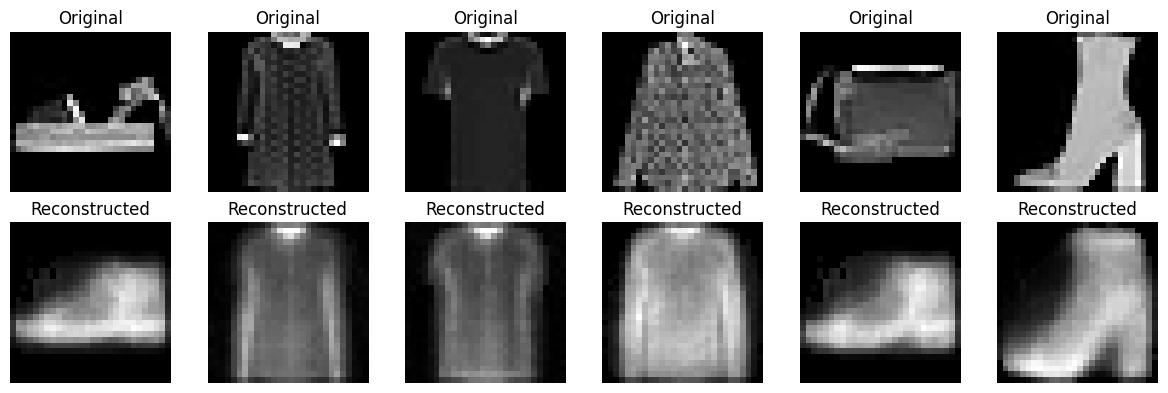

In [11]:
import matplotlib.pyplot as plt

model.eval()
x, _ = next(iter(val_loader))
x = x.view(x.size(0), -1).to(device)
with torch.no_grad():
    x_hat = model(x)

fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i in range(6):
    axes[0, i].imshow(x[i].view(28, 28).cpu(), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title("Original")
    axes[1, i].imshow(x_hat[i].view(28, 28).cpu(), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title("Reconstructed")
plt.tight_layout()
plt.savefig('autoencoder_reconstructions.png', dpi=150, bbox_inches='tight')
plt.show()